<a href="https://colab.research.google.com/github/uguazelli/scikit_learn/blob/main/linear_regression101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

$$
\hat{y} = \sum_{i=1}^{n} w_i x_i + b
$$

Where:

𝑦^​ = predicted value

𝑥𝑖​ = input feature

𝑛 = number of input features

𝑏 = intercept (bias)

𝑤𝑖 = learned weight for feature

### 🔁 Gradient Descent Update Rules

For each parameter \( w_i \) (weight), we update it like this:

$$
w_i := w_i - \alpha \cdot \frac{\partial \text{Loss}}{\partial w_i}
$$

And for the bias term \( b \):

$$
b := b - \alpha \cdot \frac{\partial \text{Loss}}{\partial b}
$$

---

### 🧠 Where:

- \( α ) = **learning rate** (controls the step size)
- \( ∂Loss / ∂wi \) = **gradient** of the loss with respect to \( 𝑤𝑖 \) (i.e., how much changing \( 𝑤𝑖 \) affects the error)
- \( := \) means **"update the value of..."**

---

We always move **against the gradient** because it points uphill — and we want to go downhill to minimize the error.

### 🔁 How is \( 𝑤𝑖  \) learned?

Using **Gradient Descent**, the model starts with random values for \( 𝑤𝑖  \) and updates them to reduce the prediction error:

$$
w_i := w_i - \alpha \cdot \frac{\partial \text{Loss}}{\partial w_i}
$$

So, \( 𝑤𝑖  \) is the result of training — the final number the model learns for each input variable.

**Zero or close to zero is the goal**

If the gradient is positive, it means increasing the weight increases the error — so we must decrease the weight.

If the gradient is negative, it means increasing the weight decreases the error — so we must increase the weight.


### 🧮 Derivatives for Gradient Descent in Linear Regression

We use **Mean Squared Error (MSE)** as the loss function:

$$
\text{Loss} = \frac{1}{m} \sum_{j=1}^{m} \left( y^{(j)} - \hat{y}^{(j)} \right)^2
$$

Where:

- \( m ) is the number of training examples  
- \( y(j) ) is the true value  
- \( y^(j) = sum from i = 1 to n of (wi times xi of j) + b ) is the predicted value.

---

### 🔁 Gradient (Partial Derivatives) for Each Weight and Bias:

For each weight:

$$
\frac{\partial \text{Loss}}{\partial w_i} = -\frac{2}{m} \sum_{j=1}^{m} \left( y^{(j)} - \hat{y}^{(j)} \right) x_i^{(j)}
$$

For the bias:

$$
\frac{\partial \text{Loss}}{\partial b} = -\frac{2}{m} \sum_{j=1}^{m} \left( y^{(j)} - \hat{y}^{(j)} \right)
$$

---

These values are plugged into the update rules:

To update each weight 𝑤𝑖 , subtract the learning rate times the gradient of the loss with respect to that weight.

To update the bias 𝑏, subtract the learning rate times the gradient of the loss with respect to the bias.

They tell the model how to adjust each parameter to reduce the prediction error.


🔧 1. Setup

In [ ]:
!pip install numpy scikit-learn matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import pandas as pd

| Column      | Description               |
| ----------- | ------------------------- |
| total\_bill | Total bill (numeric)      |
| tip         | Tip given (numeric)       |
| sex         | Gender of customer        |
| smoker      | Whether smoker or not     |
| day         | Day of week               |
| time        | Lunch or Dinner           |
| size        | Number of people at table |


In [ ]:
# Load the dataset
df = sns.load_dataset('tips')

# Show first rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Predict tip using one column

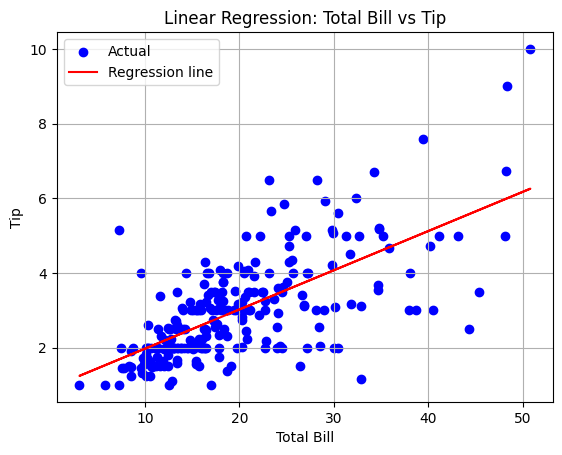

Slope (coef): 0.10502451738435337
Intercept: 0.9202696135546731


In [ ]:
# Feature and target
X = df[['total_bill']]
y = df['tip']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predictions
predictions = model.predict(X)

# Plot
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, predictions, color='red', label='Regression line')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Linear Regression: Total Bill vs Tip')
plt.legend()
plt.grid(True)
plt.show()

# Print model info
print("Slope (coef):", model.coef_[0])
print("Intercept:", model.intercept_)

# Use the model

In [ ]:
# Predict the tip for a $30 bill
new_data = pd.DataFrame({'total_bill': [30]})
predicted_tip = model.predict(new_data)
print("Predicted tip for $30 bill:", predicted_tip[0])

new_data = pd.DataFrame({'total_bill': [15, 50, 80]})
predictions = model.predict(new_data)
print("Predicted tips:", predictions)

Predicted tip for $30 bill: 4.071005135085274


# Predict tip using multiple columns

In [ ]:
# Separate features and target
X = df[['total_bill', 'sex', 'smoker', 'day', 'time', 'size']]
y = df['tip']               # what we want to predict

# Turn text columns into numbers so the model can understand them.
# Remove one column per group to avoid confusing the model with duplicate info.
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()


,total_bill,size,sex_Female,smoker_No,day_Fri,day_Sat,day_Sun,time_Dinner
0,16.99,2,True,True,False,False,True,True
1,10.34,3,False,True,False,False,True,True
2,21.01,3,False,True,False,False,True,True
3,23.68,2,False,True,False,False,True,True
4,24.59,4,True,True,False,False,True,True


In [ ]:
model = LinearRegression()
model.fit(X_encoded, y)


LinearRegression()

In [ ]:
# Create a readable DataFrame of feature weights
# 📊 This tells you how much each feature influences the tip.
coeff_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

       Feature  Coefficient
0   total_bill     0.094487
1         size     0.175992
2   sex_Female     0.032441
3    smoker_No     0.086408
4      day_Fri     0.162259
5      day_Sat     0.040801
6      day_Sun     0.136779
7  time_Dinner    -0.068129


In [ ]:
# Predict on the same data (for demo)
predictions = model.predict(X_encoded)

# Compare predicted vs actual
df_result = df.copy()
df_result['Predicted Tip'] = predictions
df_result[['total_bill', 'size', 'tip', 'Predicted Tip']].head()


,total_bill,size,tip,Predicted Tip
0,16.99,2,1.01,2.735655
1,10.34,3,1.66,2.250867
2,21.01,3,3.50,3.259044
3,23.68,2,3.31,3.335332
4,24.59,4,3.61,3.805740


# Use the Model

In [ ]:
# 1. Get the columns used during training
expected_columns = X_encoded.columns

# 2. Create your new input (raw)
new_data = pd.DataFrame([{
    'total_bill': 25,
    'size': 2,
    'sex': 'Female',
    'smoker': 'No',
    'day': 'Sun',
    'time': 'Dinner'
}])

# 3. One-hot encode new input
new_data_encoded = pd.get_dummies(new_data)

# 4. Add missing columns with 0s, and re-order
for col in expected_columns:
    if col not in new_data_encoded.columns:
        new_data_encoded[col] = 0

new_data_encoded = new_data_encoded[expected_columns]

# 5. Predict
predicted_tip = model.predict(new_data_encoded)
print("Predicted Tip:", predicted_tip[0])


Predicted Tip: 3.4924957784209565
